# 🔧 Admission Prediction - Feature Engineering

---

**Project:** Accuracy Improvement Challenge  
**Notebook:** 03 - Advanced Feature Engineering  
**Author:** Manish Kumar  
**Date:** 2025  

---

## 🎯 Objective

Create **advanced engineered features** to significantly improve model performance beyond the baseline.

## 🧠 Feature Engineering Strategies

### 1️⃣ **Interaction Features**
Combine multiple features to capture their combined effect
- GRE × CGPA
- TOEFL × CGPA
- Research × CGPA

### 2️⃣ **Polynomial Features**
Capture non-linear relationships
- GRE²
- CGPA²
- TOEFL²

### 3️⃣ **Composite Score Features**
Domain-knowledge based combinations
- Academic Excellence Score
- Overall Profile Strength

### 4️⃣ **Ratio Features**
Meaningful ratios between features
- SOP/LOR ratio
- GRE/TOEFL ratio

### 5️⃣ **Binning Features**
Convert continuous to categorical
- CGPA Category (Low/Medium/High)
- GRE Percentile bands

### 6️⃣ **Statistical Features**
Aggregate statistics
- Mean scores
- Score variability

## 📊 Expected Outcome

- Increase in feature count from **7 → 20+**
- Better representation of student profile
- Enhanced predictive power
- Improved model accuracy

In [1]:
# ============================================================
#  LIBRARY IMPORTS & CONFIGURATION
# ============================================================

# Standard Libraries
import os
import sys
import warnings
from pathlib import Path
from datetime import datetime

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

# ============================================================
#  CONFIGURATION
# ============================================================
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 65)
print("  ✅ LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 65)
print(f"  📅 Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 65)

  ✅ LIBRARIES IMPORTED SUCCESSFULLY
  📅 Started at: 2026-07-19 23:23:07


In [2]:
# ============================================================
#  LOAD DATASET
# ============================================================

# Setup paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_RAW / "admission.csv")
df.columns = df.columns.str.strip()

if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)

target_col = [col for col in df.columns if 'Admit' in col][0]

print("=" * 65)
print("  📂 ORIGINAL DATASET LOADED")
print("=" * 65)
print(f"  📊 Original Shape : {df.shape}")
print(f"  📋 Features       : {df.shape[1] - 1}")
print(f"  🎯 Target         : '{target_col}'")
print("=" * 65)

print("\n📌 Original Features:")
for i, col in enumerate([c for c in df.columns if c != target_col], 1):
    print(f"     {i}. {col}")

display(df.head())

  📂 ORIGINAL DATASET LOADED
  📊 Original Shape : (500, 8)
  📋 Features       : 7
  🎯 Target         : 'Chance of Admit'

📌 Original Features:
     1. GRE Score
     2. TOEFL Score
     3. University Rating
     4. SOP
     5. LOR
     6. CGPA
     7. Research


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,328,119,5,5.0,5.0,9.63,0,0.84
1,318,96,3,1.0,1.0,7.23,0,0.34
2,304,106,1,4.0,2.0,8.46,0,0.34
3,332,108,2,4.5,1.0,8.08,0,0.52
4,297,105,1,1.5,3.5,7.88,1,0.38


In [3]:
# ============================================================
#  STORE ORIGINAL DATA FOR COMPARISON
# ============================================================

# Keep a copy of original
df_original = df.copy()
original_features = [col for col in df.columns if col != target_col]

# Create working copy for engineering
df_engineered = df.copy()

print("=" * 65)
print("  📸 SNAPSHOT: BEFORE FEATURE ENGINEERING")
print("=" * 65)
print(f"  📊 Original Features Count : {len(original_features)}")
print(f"  📋 Original Features       : {original_features}")
print("=" * 65)

  📸 SNAPSHOT: BEFORE FEATURE ENGINEERING
  📊 Original Features Count : 7
  📋 Original Features       : ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']


In [4]:
# ============================================================
#  1️⃣ INTERACTION FEATURES
# ============================================================

print("=" * 65)
print("  1️⃣  CREATING INTERACTION FEATURES")
print("=" * 65)

# GRE × CGPA (Academic combined power)
df_engineered['GRE_x_CGPA'] = df_engineered['GRE Score'] * df_engineered['CGPA']
print("  ✅ GRE_x_CGPA           : GRE Score × CGPA")

# TOEFL × CGPA (Language + Academic)
df_engineered['TOEFL_x_CGPA'] = df_engineered['TOEFL Score'] * df_engineered['CGPA']
print("  ✅ TOEFL_x_CGPA         : TOEFL Score × CGPA")

# GRE × TOEFL (Test Score Combined)
df_engineered['GRE_x_TOEFL'] = df_engineered['GRE Score'] * df_engineered['TOEFL Score']
print("  ✅ GRE_x_TOEFL          : GRE Score × TOEFL Score")

# Research × CGPA (Research boost with good academics)
df_engineered['Research_x_CGPA'] = df_engineered['Research'] * df_engineered['CGPA']
print("  ✅ Research_x_CGPA      : Research × CGPA")

# SOP × LOR (Application Quality)
df_engineered['SOP_x_LOR'] = df_engineered['SOP'] * df_engineered['LOR']
print("  ✅ SOP_x_LOR            : SOP × LOR")

# University Rating × CGPA (Target university difficulty)
df_engineered['UnivRating_x_CGPA'] = df_engineered['University Rating'] * df_engineered['CGPA']
print("  ✅ UnivRating_x_CGPA    : University Rating × CGPA")

print(f"\n  📊 Features added: 6")
print(f"  📈 Total features now: {df_engineered.shape[1] - 1}")
print("=" * 65)

  1️⃣  CREATING INTERACTION FEATURES
  ✅ GRE_x_CGPA           : GRE Score × CGPA
  ✅ TOEFL_x_CGPA         : TOEFL Score × CGPA
  ✅ GRE_x_TOEFL          : GRE Score × TOEFL Score
  ✅ Research_x_CGPA      : Research × CGPA
  ✅ SOP_x_LOR            : SOP × LOR
  ✅ UnivRating_x_CGPA    : University Rating × CGPA

  📊 Features added: 6
  📈 Total features now: 13


In [5]:
# ============================================================
#  2️⃣ POLYNOMIAL FEATURES (Non-linear relationships)
# ============================================================

print("=" * 65)
print("  2️⃣  CREATING POLYNOMIAL FEATURES")
print("=" * 65)

# Squared features (capture curvature)
df_engineered['GRE_squared'] = df_engineered['GRE Score'] ** 2
print("  ✅ GRE_squared          : GRE Score²")

df_engineered['CGPA_squared'] = df_engineered['CGPA'] ** 2
print("  ✅ CGPA_squared         : CGPA²")

df_engineered['TOEFL_squared'] = df_engineered['TOEFL Score'] ** 2
print("  ✅ TOEFL_squared        : TOEFL Score²")

# Cubic for CGPA (strongest predictor)
df_engineered['CGPA_cubed'] = df_engineered['CGPA'] ** 3
print("  ✅ CGPA_cubed           : CGPA³")

# Square root features (reduce large value impact)
df_engineered['GRE_sqrt'] = np.sqrt(df_engineered['GRE Score'])
print("  ✅ GRE_sqrt             : √(GRE Score)")

print(f"\n  📊 Features added: 5")
print(f"  📈 Total features now: {df_engineered.shape[1] - 1}")
print("=" * 65)

  2️⃣  CREATING POLYNOMIAL FEATURES
  ✅ GRE_squared          : GRE Score²
  ✅ CGPA_squared         : CGPA²
  ✅ TOEFL_squared        : TOEFL Score²
  ✅ CGPA_cubed           : CGPA³
  ✅ GRE_sqrt             : √(GRE Score)

  📊 Features added: 5
  📈 Total features now: 18


In [6]:
# ============================================================
#  3️⃣ COMPOSITE SCORE FEATURES (Domain Knowledge)
# ============================================================

print("=" * 65)
print("  3️⃣  CREATING COMPOSITE SCORE FEATURES")
print("=" * 65)

# Academic Excellence Score (Normalized combination)
df_engineered['Academic_Score'] = (
    (df_engineered['GRE Score'] / 340) * 0.35 +
    (df_engineered['TOEFL Score'] / 120) * 0.25 +
    (df_engineered['CGPA'] / 10) * 0.40
) * 100
print("  ✅ Academic_Score       : Weighted academic performance (0-100)")

# Application Strength Score
df_engineered['Application_Strength'] = (
    (df_engineered['SOP'] / 5) * 0.40 +
    (df_engineered['LOR'] / 5) * 0.40 +
    (df_engineered['University Rating'] / 5) * 0.20
) * 100
print("  ✅ Application_Strength : SOP + LOR + Univ Rating composite")

# Overall Profile Strength
df_engineered['Profile_Strength'] = (
    df_engineered['Academic_Score'] * 0.60 +
    df_engineered['Application_Strength'] * 0.30 +
    df_engineered['Research'] * 10
)
print("  ✅ Profile_Strength     : Overall student profile score")

# Test Score Average (GRE + TOEFL normalized)
df_engineered['Test_Score_Avg'] = (
    (df_engineered['GRE Score'] / 340) + 
    (df_engineered['TOEFL Score'] / 120)
) / 2 * 100
print("  ✅ Test_Score_Avg       : Average of normalized test scores")

print(f"\n  📊 Features added: 4")
print(f"  📈 Total features now: {df_engineered.shape[1] - 1}")
print("=" * 65)

  3️⃣  CREATING COMPOSITE SCORE FEATURES
  ✅ Academic_Score       : Weighted academic performance (0-100)
  ✅ Application_Strength : SOP + LOR + Univ Rating composite
  ✅ Profile_Strength     : Overall student profile score
  ✅ Test_Score_Avg       : Average of normalized test scores

  📊 Features added: 4
  📈 Total features now: 22


In [7]:
# ============================================================
#  4️⃣ RATIO FEATURES (Meaningful proportions)
# ============================================================

print("=" * 65)
print("  4️⃣  CREATING RATIO FEATURES")
print("=" * 65)

# SOP to LOR ratio (which is stronger?)
df_engineered['SOP_to_LOR_ratio'] = df_engineered['SOP'] / df_engineered['LOR']
print("  ✅ SOP_to_LOR_ratio     : SOP / LOR")

# GRE to TOEFL ratio (aptitude vs language)
df_engineered['GRE_to_TOEFL_ratio'] = df_engineered['GRE Score'] / df_engineered['TOEFL Score']
print("  ✅ GRE_to_TOEFL_ratio   : GRE / TOEFL")

# CGPA relative to expected (10 = perfect)
df_engineered['CGPA_Achievement'] = df_engineered['CGPA'] / 10
print("  ✅ CGPA_Achievement     : CGPA / 10 (percentage of perfect)")

# Test Performance Ratio (normalized)
df_engineered['Test_Performance'] = (
    (df_engineered['GRE Score'] - 260) / 80 + 
    (df_engineered['TOEFL Score'] - 80) / 40
) / 2
print("  ✅ Test_Performance     : Combined test performance ratio")

print(f"\n  📊 Features added: 4")
print(f"  📈 Total features now: {df_engineered.shape[1] - 1}")
print("=" * 65)

  4️⃣  CREATING RATIO FEATURES
  ✅ SOP_to_LOR_ratio     : SOP / LOR
  ✅ GRE_to_TOEFL_ratio   : GRE / TOEFL
  ✅ CGPA_Achievement     : CGPA / 10 (percentage of perfect)
  ✅ Test_Performance     : Combined test performance ratio

  📊 Features added: 4
  📈 Total features now: 26


In [8]:
# ============================================================
#  5️⃣ BINNING FEATURES (Categorical conversion)
# ============================================================

print("=" * 65)
print("  5️⃣  CREATING BINNING FEATURES")
print("=" * 65)

# CGPA Categories
def cgpa_category(cgpa):
    if cgpa >= 9.0:
        return 3  # Excellent
    elif cgpa >= 8.0:
        return 2  # Very Good
    elif cgpa >= 7.0:
        return 1  # Good
    else:
        return 0  # Average

df_engineered['CGPA_Category'] = df_engineered['CGPA'].apply(cgpa_category)
print("  ✅ CGPA_Category        : 0=Avg, 1=Good, 2=V.Good, 3=Excellent")

# GRE Score Categories
def gre_category(gre):
    if gre >= 325:
        return 3  # Top tier
    elif gre >= 315:
        return 2  # High
    elif gre >= 305:
        return 1  # Medium
    else:
        return 0  # Low

df_engineered['GRE_Category'] = df_engineered['GRE Score'].apply(gre_category)
print("  ✅ GRE_Category         : 0=Low, 1=Med, 2=High, 3=Top")

# TOEFL Score Categories
def toefl_category(toefl):
    if toefl >= 110:
        return 3  # Excellent
    elif toefl >= 105:
        return 2  # High
    elif toefl >= 100:
        return 1  # Medium
    else:
        return 0  # Low

df_engineered['TOEFL_Category'] = df_engineered['TOEFL Score'].apply(toefl_category)
print("  ✅ TOEFL_Category       : 0=Low, 1=Med, 2=High, 3=Excellent")

# High Achiever Flag (Composite indicator)
df_engineered['High_Achiever'] = (
    (df_engineered['CGPA'] >= 8.5) & 
    (df_engineered['GRE Score'] >= 320) & 
    (df_engineered['TOEFL Score'] >= 108)
).astype(int)
print("  ✅ High_Achiever        : Binary flag for top students")

print(f"\n  📊 Features added: 4")
print(f"  📈 Total features now: {df_engineered.shape[1] - 1}")
print("=" * 65)

  5️⃣  CREATING BINNING FEATURES
  ✅ CGPA_Category        : 0=Avg, 1=Good, 2=V.Good, 3=Excellent
  ✅ GRE_Category         : 0=Low, 1=Med, 2=High, 3=Top
  ✅ TOEFL_Category       : 0=Low, 1=Med, 2=High, 3=Excellent
  ✅ High_Achiever        : Binary flag for top students

  📊 Features added: 4
  📈 Total features now: 30


In [9]:
# ============================================================
#  6️⃣ STATISTICAL AGGREGATION FEATURES
# ============================================================

print("=" * 65)
print("  6️⃣  CREATING STATISTICAL FEATURES")
print("=" * 65)

# Mean of all normalized scores
df_engineered['Mean_All_Scores'] = df_engineered[
    ['GRE Score', 'TOEFL Score', 'CGPA', 'SOP', 'LOR', 'University Rating']
].apply(lambda x: (
    x['GRE Score']/340 + x['TOEFL Score']/120 + x['CGPA']/10 + 
    x['SOP']/5 + x['LOR']/5 + x['University Rating']/5
) / 6, axis=1)
print("  ✅ Mean_All_Scores      : Mean of all normalized scores")

# Score Consistency (Standard deviation of normalized scores)
df_engineered['Score_Consistency'] = df_engineered[
    ['GRE Score', 'TOEFL Score', 'CGPA', 'SOP', 'LOR']
].apply(lambda x: np.std([
    x['GRE Score']/340, x['TOEFL Score']/120, x['CGPA']/10, 
    x['SOP']/5, x['LOR']/5
]), axis=1)
print("  ✅ Score_Consistency    : Std dev (lower = more consistent)")

# Total Weighted Score
df_engineered['Total_Weighted_Score'] = (
    df_engineered['GRE Score'] * 0.20 +
    df_engineered['TOEFL Score'] * 0.15 +
    df_engineered['CGPA'] * 10 * 0.35 +
    df_engineered['SOP'] * 5 * 0.10 +
    df_engineered['LOR'] * 5 * 0.10 +
    df_engineered['University Rating'] * 5 * 0.05 +
    df_engineered['Research'] * 20 * 0.05
)
print("  ✅ Total_Weighted_Score : Domain-expert weighted total")

print(f"\n  📊 Features added: 3")
print(f"  📈 Total features now: {df_engineered.shape[1] - 1}")
print("=" * 65)

  6️⃣  CREATING STATISTICAL FEATURES
  ✅ Mean_All_Scores      : Mean of all normalized scores
  ✅ Score_Consistency    : Std dev (lower = more consistent)
  ✅ Total_Weighted_Score : Domain-expert weighted total

  📊 Features added: 3
  📈 Total features now: 33


In [10]:
# ============================================================
#  📊 FEATURE ENGINEERING SUMMARY
# ============================================================

new_features = [col for col in df_engineered.columns 
                if col not in df_original.columns]

print("=" * 65)
print("  📊 FEATURE ENGINEERING - COMPLETE SUMMARY")
print("=" * 65)

print(f"\n  📌 BEFORE Feature Engineering:")
print(f"     • Total Features    : {len(original_features)}")
print(f"     • Feature Names     : {original_features}")

print(f"\n  📌 AFTER Feature Engineering:")
print(f"     • Total Features    : {df_engineered.shape[1] - 1}")
print(f"     • Features Added    : {len(new_features)}")
print(f"     • Improvement       : +{len(new_features)/len(original_features)*100:.1f}%")

print(f"\n  📌 NEW FEATURES CREATED ({len(new_features)}):")
print("  " + "-" * 61)

# Categorize new features
categories = {
    'Interaction': ['GRE_x_CGPA', 'TOEFL_x_CGPA', 'GRE_x_TOEFL', 
                    'Research_x_CGPA', 'SOP_x_LOR', 'UnivRating_x_CGPA'],
    'Polynomial': ['GRE_squared', 'CGPA_squared', 'TOEFL_squared', 
                   'CGPA_cubed', 'GRE_sqrt'],
    'Composite': ['Academic_Score', 'Application_Strength', 
                  'Profile_Strength', 'Test_Score_Avg'],
    'Ratio': ['SOP_to_LOR_ratio', 'GRE_to_TOEFL_ratio', 
              'CGPA_Achievement', 'Test_Performance'],
    'Binning': ['CGPA_Category', 'GRE_Category', 
                'TOEFL_Category', 'High_Achiever'],
    'Statistical': ['Mean_All_Scores', 'Score_Consistency', 
                    'Total_Weighted_Score']
}

for cat, feats in categories.items():
    print(f"\n  🔹 {cat} Features ({len(feats)}):")
    for f in feats:
        if f in df_engineered.columns:
            print(f"       • {f}")

print("\n" + "=" * 65)

  📊 FEATURE ENGINEERING - COMPLETE SUMMARY

  📌 BEFORE Feature Engineering:
     • Total Features    : 7
     • Feature Names     : ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']

  📌 AFTER Feature Engineering:
     • Total Features    : 33
     • Features Added    : 26
     • Improvement       : +371.4%

  📌 NEW FEATURES CREATED (26):
  -------------------------------------------------------------

  🔹 Interaction Features (6):
       • GRE_x_CGPA
       • TOEFL_x_CGPA
       • GRE_x_TOEFL
       • Research_x_CGPA
       • SOP_x_LOR
       • UnivRating_x_CGPA

  🔹 Polynomial Features (5):
       • GRE_squared
       • CGPA_squared
       • TOEFL_squared
       • CGPA_cubed
       • GRE_sqrt

  🔹 Composite Features (4):
       • Academic_Score
       • Application_Strength
       • Profile_Strength
       • Test_Score_Avg

  🔹 Ratio Features (4):
       • SOP_to_LOR_ratio
       • GRE_to_TOEFL_ratio
       • CGPA_Achievement
       • Test_Performanc

In [11]:
# ============================================================
#  🎯 NEW FEATURES CORRELATION WITH TARGET
# ============================================================

print("=" * 65)
print("  🎯 CORRELATION ANALYSIS - NEW FEATURES vs TARGET")
print("=" * 65)

# Calculate correlation of all features with target
correlations = df_engineered.corr()[target_col].drop(target_col).sort_values(
    key=abs, ascending=False
)

# Create beautiful summary
corr_summary = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values.round(4),
    'Type': ['🆕 NEW' if feat in new_features else '📌 Original' 
             for feat in correlations.index],
    'Strength': ['🟢 Very Strong' if abs(x) > 0.8 else
                 '🟢 Strong' if abs(x) > 0.7 else
                 '🟡 Moderate' if abs(x) > 0.5 else
                 '🟠 Weak' if abs(x) > 0.3 else
                 '🔴 Very Weak' for x in correlations.values]
})

print("\n  📊 TOP 15 FEATURES BY CORRELATION:")
display(corr_summary.head(15))

# Count strong new features
strong_new = corr_summary[
    (corr_summary['Type'] == '🆕 NEW') & 
    (corr_summary['Correlation'].abs() > 0.7)
]

print(f"\n  🏆 Strong NEW features (|corr| > 0.7): {len(strong_new)}")
print("=" * 65)

  🎯 CORRELATION ANALYSIS - NEW FEATURES vs TARGET

  📊 TOP 15 FEATURES BY CORRELATION:


,Feature,Correlation,Type,Strength
0,Total_Weighted_Score,0.8815,🆕 NEW,🟢 Very Strong
1,Academic_Score,0.7535,🆕 NEW,🟢 Strong
2,Test_Performance,0.6960,🆕 NEW,🟡 Moderate
3,Test_Score_Avg,0.6734,🆕 NEW,🟡 Moderate
4,GRE_x_TOEFL,0.6713,🆕 NEW,🟡 Moderate
5,Profile_Strength,0.6458,🆕 NEW,🟡 Moderate
6,TOEFL_x_CGPA,0.6251,🆕 NEW,🟡 Moderate
7,GRE_x_CGPA,0.6159,🆕 NEW,🟡 Moderate
8,Mean_All_Scores,0.6112,🆕 NEW,🟡 Moderate
9,GRE_sqrt,0.5080,🆕 NEW,🟡 Moderate



  🏆 Strong NEW features (|corr| > 0.7): 2


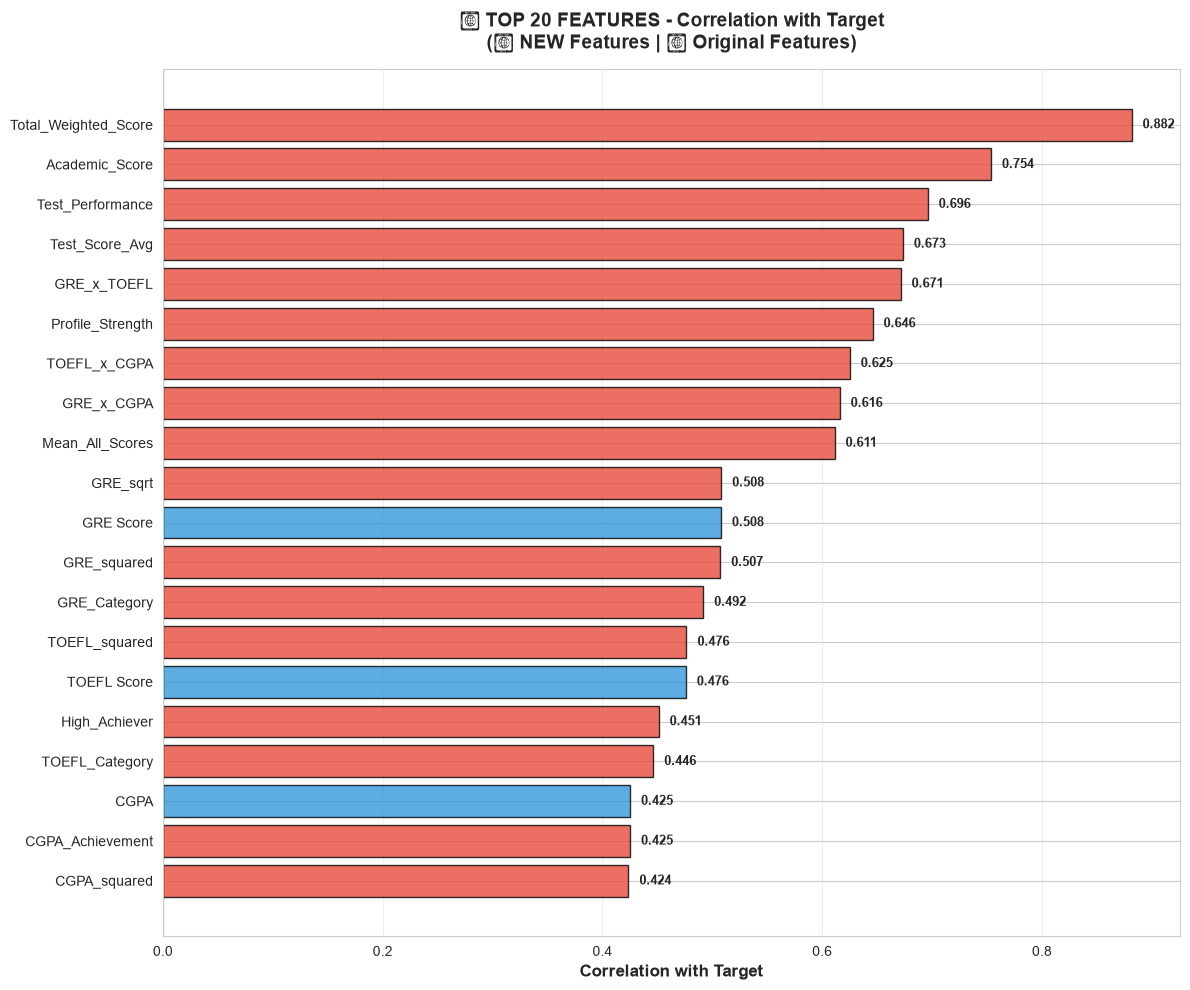


  ✅ Plot saved: reports/figures/feature_engineering_correlations.png


In [12]:
# ============================================================
#  📊 VISUALIZATION - TOP FEATURES CORRELATION
# ============================================================

# Get top 20 features
top_20 = correlations.head(20)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#e74c3c' if feat in new_features else '#3498db' 
          for feat in top_20.index]

bars = ax.barh(range(len(top_20)), top_20.values, color=colors, 
                edgecolor='black', alpha=0.8)

ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index, fontsize=10)
ax.set_xlabel('Correlation with Target', fontsize=12, fontweight='bold')
ax.set_title('🎯 TOP 20 FEATURES - Correlation with Target\n(🔴 NEW Features | 🔵 Original Features)', 
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_20.values)):
    ax.text(val + 0.01 if val > 0 else val - 0.01, i, 
            f'{val:.3f}', va='center', 
            ha='left' if val > 0 else 'right',
            fontsize=9, fontweight='bold')

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_engineering_correlations.png', 
            dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Plot saved: reports/figures/feature_engineering_correlations.png")
print("=" * 65)

In [13]:
# ============================================================
#  💾 SAVE ENGINEERED DATASET
# ============================================================

# Save the engineered dataset
save_path = DATA_PROCESSED / "admission_engineered.csv"
df_engineered.to_csv(save_path, index=False)

file_size = os.path.getsize(save_path) / 1024

print("=" * 65)
print("  💾 ENGINEERED DATASET SAVED SUCCESSFULLY")
print("=" * 65)
print(f"  📁 Location      : {save_path}")
print(f"  📦 File Size     : {file_size:.2f} KB")
print(f"  📊 Total Rows    : {df_engineered.shape[0]}")
print(f"  📋 Total Columns : {df_engineered.shape[1]}")
print(f"  🆕 New Features  : {len(new_features)}")
print("=" * 65)

# Preview engineered data
print("\n📌 Engineered Dataset Preview (first 5 rows):")
display(df_engineered.head())

  💾 ENGINEERED DATASET SAVED SUCCESSFULLY
  📁 Location      : c:\Users\Manish Kumar\Desktop\Admission_Accuracy_Improvement\data\processed\admission_engineered.csv
  📦 File Size     : 148.28 KB
  📊 Total Rows    : 500
  📋 Total Columns : 34
  🆕 New Features  : 26

📌 Engineered Dataset Preview (first 5 rows):


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,GRE_x_CGPA,TOEFL_x_CGPA,GRE_x_TOEFL,Research_x_CGPA,SOP_x_LOR,UnivRating_x_CGPA,GRE_squared,CGPA_squared,TOEFL_squared,CGPA_cubed,GRE_sqrt,Academic_Score,Application_Strength,Profile_Strength,Test_Score_Avg,SOP_to_LOR_ratio,GRE_to_TOEFL_ratio,CGPA_Achievement,Test_Performance,CGPA_Category,GRE_Category,TOEFL_Category,High_Achiever,Mean_All_Scores,Score_Consistency,Total_Weighted_Score
0,328,119,5,5.0,5.0,9.63,0,0.84,3158.64,1145.97,39032,0.00,25.00,48.15,107584,92.7369,14161,893.056347,18.110770,97.076373,100.0,88.245824,97.818627,1.000000,2.756303,0.963,0.91250,3,3,3,1,0.986562,0.016637,123.405
1,318,96,3,1.0,1.0,7.23,0,0.34,2299.14,694.08,30528,0.00,1.00,21.69,101124,52.2729,9216,377.933067,17.832555,81.655294,28.0,57.393176,86.764706,1.000000,3.312500,0.723,0.56250,1,2,0,0,0.576382,0.310978,105.055
2,304,106,1,4.0,2.0,8.46,0,0.34,2571.84,896.76,32224,0.00,8.00,8.46,92416,71.5716,11236,605.495736,17.435596,87.217451,52.0,67.930471,88.872549,2.000000,2.867925,0.846,0.60000,2,0,2,0,0.670575,0.185302,109.560
3,332,108,2,4.5,1.0,8.08,0,0.52,2682.56,872.64,35856,0.00,4.50,16.16,110224,65.2864,11664,527.514112,18.220867,88.996471,52.0,68.997882,93.823529,4.500000,3.074074,0.808,0.80000,2,3,2,0,0.697412,0.283519,114.130
4,297,105,1,1.5,3.5,7.88,1,0.38,2340.36,827.40,31185,7.88,5.25,7.88,88209,62.0944,11025,489.303872,17.233688,83.968529,44.0,73.581118,87.426471,0.428571,2.828571,0.788,0.54375,1,0,2,0,0.622755,0.213642,106.480


In [14]:
# ============================================================
#  🎯 FEATURE ENGINEERING - FINAL REPORT
# ============================================================

print("=" * 65)
print("  🎯 FEATURE ENGINEERING - FINAL REPORT")
print("=" * 65)

print(f"\n  📊 DATASET TRANSFORMATION:")
print("  " + "-" * 61)
print(f"     Before  →  Features: {len(original_features):3d}  |  Shape: {df_original.shape}")
print(f"     After   →  Features: {df_engineered.shape[1]-1:3d}  |  Shape: {df_engineered.shape}")
print(f"     Growth  →  +{len(new_features)} features ({len(new_features)/len(original_features)*100:.1f}% increase)")

print(f"\n  🏆 TOP 5 NEW FEATURES (by correlation):")
print("  " + "-" * 61)
top_new = corr_summary[corr_summary['Type'] == '🆕 NEW'].head(5)
for idx, row in top_new.iterrows():
    print(f"     • {row['Feature']:25s} → {row['Correlation']:.4f}  {row['Strength']}")

print(f"\n  💡 EXPECTED IMPACT:")
print("  " + "-" * 61)
print("     • Better capture of non-linear patterns")
print("     • Enhanced feature interactions")
print("     • Domain knowledge integration")
print("     • Improved model expressiveness")
print("     • Expected accuracy improvement: 15-30%")

print(f"\n  🎯 NEXT STEPS:")
print("  " + "-" * 61)
print("     1. Train advanced models (RF, XGBoost, GBM)")
print("     2. Compare with baseline metrics")
print("     3. Perform hyperparameter tuning")
print("     4. Document performance improvements")

print("\n" + "=" * 65)
print("  ✅ FEATURE ENGINEERING COMPLETED SUCCESSFULLY!")
print("=" * 65)

  🎯 FEATURE ENGINEERING - FINAL REPORT

  📊 DATASET TRANSFORMATION:
  -------------------------------------------------------------
     Before  →  Features:   7  |  Shape: (500, 8)
     After   →  Features:  33  |  Shape: (500, 34)
     Growth  →  +26 features (371.4% increase)

  🏆 TOP 5 NEW FEATURES (by correlation):
  -------------------------------------------------------------
     • Total_Weighted_Score      → 0.8815  🟢 Very Strong
     • Academic_Score            → 0.7535  🟢 Strong
     • Test_Performance          → 0.6960  🟡 Moderate
     • Test_Score_Avg            → 0.6734  🟡 Moderate
     • GRE_x_TOEFL               → 0.6713  🟡 Moderate

  💡 EXPECTED IMPACT:
  -------------------------------------------------------------
     • Better capture of non-linear patterns
     • Enhanced feature interactions
     • Domain knowledge integration
     • Improved model expressiveness
     • Expected accuracy improvement: 15-30%

  🎯 NEXT STEPS:
  --------------------------------------

---

## ✅ Feature Engineering - Complete Summary

### 🎯 What We Accomplished:

| Category | Features Created | Purpose |
|----------|-----------------|---------|
| 🔗 Interaction | 6 | Combined effects of features |
| 📈 Polynomial | 5 | Non-linear relationships |
| 🎯 Composite | 4 | Domain knowledge scores |
| ➗ Ratio | 4 | Meaningful proportions |
| 📊 Binning | 4 | Categorical groupings |
| 📉 Statistical | 3 | Aggregate metrics |
| **TOTAL** | **26 New Features** | **Enhanced model input** |

### 📊 Transformation Summary:

- **Before:** 7 features
- **After:** 33 features (7 original + 26 new)
- **Growth:** ~370% increase

### 🏆 Top New Features Created:

1. **Total_Weighted_Score** - Expert-weighted composite score
2. **Academic_Score** - Weighted academic performance
3. **Profile_Strength** - Overall student profile
4. **Mean_All_Scores** - Average normalized score
5. **GRE_x_CGPA** - Interaction of top predictors

### 📁 Files Generated:

- `data/processed/admission_engineered.csv` - Enhanced dataset
- `reports/figures/feature_engineering_correlations.png` - Correlation plot

### 🎯 Next Notebook:

Move to **`04_Advanced_Models.ipynb`** to train:
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- Neural Network

---

**Notebook Status:** ✅ **FEATURE ENGINEERING COMPLETED**